In [1]:
import ratinabox
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells
from ratinabox.contribs.NeuralNetworkNeurons import NeuralNetworkNeurons #for the Actor and Critic
from ratinabox.contribs.TaskEnvironment import (SpatialGoalEnvironment, SpatialGoal, Reward)

#misc
import torch 
import numpy as np 
from gymnasium.spaces import Box
from tqdm import tqdm
import time
import random

from plotting_utils import *
from base_actor_critic import *
from training_utils import *

In [7]:
#TASK CONSTANTS
DT = 0.1 # Time step
T_TIMEOUT = 50 # Time out
GOAL_POS = np.array([0.9, 0.05]) # Goal position
WALL = [[0.8, 0.0], [0.8, 0.8]]
GOAL_RADIUS = 0.1
REWARD = 1 # Reward
REWARD_DURATION = 1 # Reward duration

#LEARNING CONSTANTS
TAU = 5 # Discount time horizon
TAU_E = 5 # Eligibility trace time horizon
ETA = 0.01 # Learning rate 
N_EPISODES = 5000 # Number of episodes
L2 = 0.000 # L2 regularization

In [8]:
env, ag = generate_navigation_task_env(dt=DT,reward=REWARD, reward_duration=REWARD_DURATION, goal_pos=GOAL_POS, goal_radius=GOAL_RADIUS, wall=WALL) 

(<Figure size 250x250 with 1 Axes>, <Axes: >)

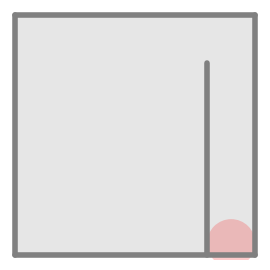

In [9]:
fig, ax = env.plot_environment()
display_reward_patch(fig,ax,reward_pos=[0.9, 0.05], reward_radius=0.1)

 fta_eta: 0.2, n_tilings: 1, n_tiles: 10
 fta_eta: 0.2, n_tilings: 1, n_tiles: 10


Text(0.5, 1.0, 'Vy')

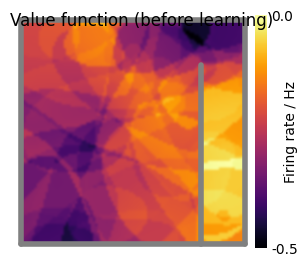

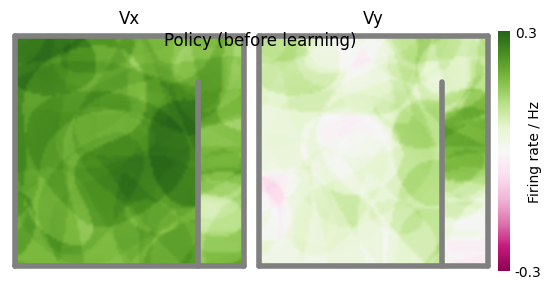

In [10]:
placecells = PlaceCells(ag, params={'n':200,}) 

#Make the actor and the critic (first make their core NNs then pass these to the full Actor and Critic classes)
# actorNN  = VxVyGaussianFTU(n_in=placecells.n)
actorNN  = VxVyGaussianFTU(n_in=placecells.n,post_fta=[2])
criticNN = FTANetwork(n_in=placecells.n,post_fta=[1])
#
actor  = Actor(ag, params = {'input_layers':[placecells], 'NeuralNetworkModule':actorNN}); actor.colormap="PiYG"
critic = Critic(ag, params = {'input_layers':[placecells], 'NeuralNetworkModule':criticNN})

#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")

In [ ]:
train_agent_episodes(env, ag, actor, critic, placecells, n_episodes=N_EPISODES, time_limit=T_TIMEOUT)

<success fraction>: 0.01, <episode time>: 49.6:  13%|█▎        | 663/5000 [10:01<1:05:38,  1.10it/s]

(<Figure size 250x250 with 1 Axes>, <Axes: >)

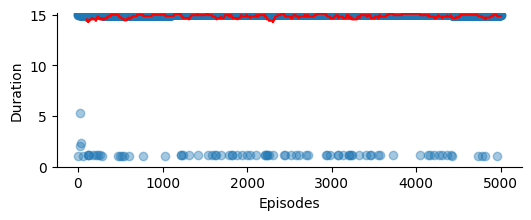

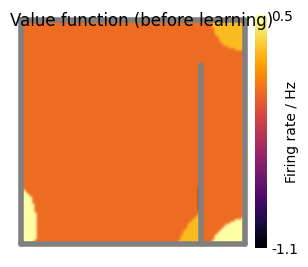

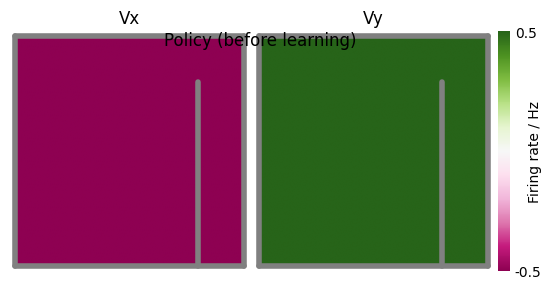

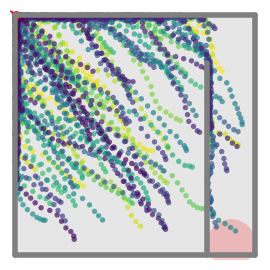

In [13]:
#This plots the reward history over training
fig, ax = plot_reward_history(env)
#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")
#Shows the trajectory of the agent over the last 100 episodes
fig, ax = ag.plot_trajectory(color="changing",t_start=env.episodes['start'][-100],t_end=env.episodes['start'][-1],); display_reward_patch(fig,ax, reward_pos=[0.9, 0.05], reward_radius=0.1)